In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.dates as mdates
import xarray as xr
import pandas as pd
import numpy as np
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
from scipy.stats import linregress

# Append custom toolbox to the path
sys.path.append('../src')
import bipolarMhwToolBox as MHW


%matplotlib inline

In [15]:
def plotmap(data, ax=None):
    """
    Plots a simple Cartopy map with land in grey. The map extent is derived 
    from the provided dataset's latitude and longitude coordinates.

    Parameters
    ----------
    data : xarray.DataArray or xarray.Dataset
        Data containing lat and lon coordinates. Must have data.lat and data.lon
        that can be used to determine the spatial extent.
    ax : matplotlib.axes.Axes or None, optional
        The axes object on which to plot. If None, a new figure and axes are created.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes object containing the plot.
    """
    # Extract min/max lat/lon from the data
    min_lat = float(data.lat.min())
    max_lat = float(data.lat.max())
    min_lon = float(data.lon.min())
    max_lon = float(data.lon.max())

    # Create a new figure and axis if none is provided
    if ax is None:
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())
    else:
        # Ensure the provided axis uses Plate Carree projection
        if not isinstance(ax.projection, ccrs.PlateCarree):
            raise ValueError("The provided axis must have a Plate Carree projection.")

    # Add land in grey
    ax.add_feature(cfeature.LAND, facecolor='grey')

    # Add features to the map
    ax.coastlines(resolution='10m', linewidth=1)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # Set the extent from the data
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    return ax

### open datasets

In [16]:
#Temperature
ds = xr.open_dataset('../data/WA_OISST_1989_2018.nc')
clim = xr.open_dataset('../data/clim_thresh_1989_2018_baseline.nc')
sev = xr.open_dataset('../data/WA_OISST_severity_1989_2018.nc')

# chlorophyll
ch = xr.open_dataset('../data/IMOS_aggregation_20260508T031639Z.nc')

In [17]:
ch

<xarray.Dataset> Size: 118MB
Dimensions:    (time: 730, latitude: 201, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2010-01-01T05:30:00 ... 2011-12-31T0...
  * latitude   (latitude) float64 2kB -27.0 -27.01 -27.02 ... -28.99 -29.0
  * longitude  (longitude) float64 2kB 113.0 113.0 113.0 ... 115.0 115.0 115.0
Data variables:
    chl_oc3    (time, latitude, longitude) float32 118MB ...
Attributes:
    history:              File initialised at 2020-08-06T00:35:04.401564\nIni...
    Conventions:          CF-1.6
    source_path:          imos-srs/archive/oc/aqua/1d/v201909/2010/01/A201001...
    time_coverage_start:  2010-01-01T05:30:00Z
    time_coverage_end:    2011-12-31T05:30:00Z
    title:                ${1}, 2010-01-01T05:30:00Z, 2011-12-31T05:30:00Z
    geospatial_lat_min:   -29.0
    geospatial_lat_max:   -27.0
    geospatial_lon_min:   113.0
    geospatial_lon_max:   115.0

### prepare data for plotting

In [18]:
day = '2011-03-01'
lat_s = -28
lon_s = 113.8
sst_day = ds.sst.sel(time=day)
tseries = ds.sst.sel(lat=lat_s,lon=lon_s,method='nearest').sel(time=slice('2010-07-01','2011-12-31'))
sev_t = sev.sel(lat=lat_s,lon=lon_s,method='nearest').sel(time=slice('2010-07-01','2011-12-31'))
# Site climatology and threshold from dayofyear dataset
clim_site = clim['clim'].sel(
    lat=lat_s, lon=lon_s, method='nearest'
).squeeze(drop=True)

thresh_site = clim['thresh'].sel(
    lat=lat_s, lon=lon_s, method='nearest'
).squeeze(drop=True)

doy = tseries.time.dt.dayofyear

clim_t = xr.DataArray(
    clim_site.sel(dayofyear=doy).values,
    coords={'time': tseries.time},
    dims=['time'],
    name='clim'
)

thresh_t = xr.DataArray(
    thresh_site.sel(dayofyear=doy).values,
    coords={'time': tseries.time},
    dims=['time'],
    name='thresh'
)

tseries, clim_t, thresh_t = xr.align(tseries, clim_t, thresh_t)

# extract same timeseries for chlorophyll
ch_tseries = ch.chl_oc3.mean(['latitude','longitude']).sel(time=slice('2010-07-01','2011-12-31'))

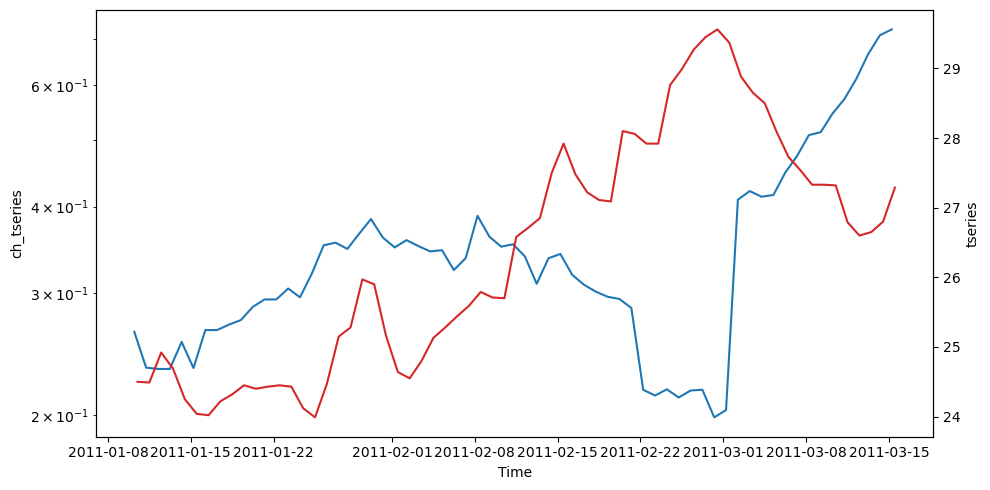

In [19]:
start = "2011-01-10"
end = "2011-03-15"

# Slice first
ch_sel = ch_tseries.sel(time=slice(start, end))
ts_sel = tseries.sel(time=slice(start, end))

# Convert to pandas Series with a DatetimeIndex
ch_pd = ch_sel.to_series().sort_index()
ts_pd = ts_sel.to_series().sort_index()

# 14-day running mean over actual time, not sample count
ch_smooth = ch_pd.rolling("14D", min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: smoothed chlorophyll on log scale
ax1.plot(ch_smooth.index, ch_smooth, label="ch_tseries (14-day mean)")
ax1.set_yscale("log")
ax1.set_ylabel("ch_tseries")
ax1.set_xlabel("Time")

# Right axis: tseries
ax2 = ax1.twinx()
ax2.plot(ts_pd.index, ts_pd, color="tab:red", label="tseries")
ax2.set_ylabel("tseries")

plt.tight_layout()
plt.show()

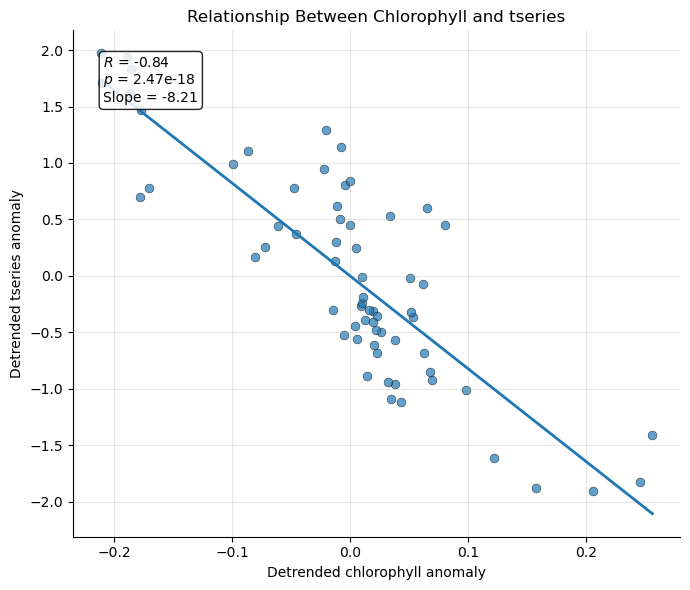

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

# ---------------------------------------------------
# PREPARE AND ALIGN THE TWO TIMESERIES
# ---------------------------------------------------

# Convert to DataFrames
ch_df = ch_smooth.rename("ch").reset_index()
ts_df = ts_pd.rename("ts").reset_index()

# Sort by time for merge_asof
ch_df = ch_df.sort_values("time")
ts_df = ts_df.sort_values("time")

# Match nearest timestamps within 1 day
df = pd.merge_asof(
    ch_df,
    ts_df,
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("1D")
).dropna()

# Remove nonpositive chlorophyll values for log scaling
df = df[df["ch"] > 0]

# ---------------------------------------------------
# EXTRACT VARIABLES
# ---------------------------------------------------

x = df["ch"].to_numpy()
y = df["ts"].to_numpy()

# Numeric time axis (days)
t = (
    (df["time"] - df["time"].min())
    .dt.total_seconds()
    / 86400
).to_numpy()

# ---------------------------------------------------
# DETREND BOTH SERIES USING ACTUAL TIME
# ---------------------------------------------------

# Chlorophyll trend
mx_t, bx_t, *_ = linregress(t, x)
x_detrended = x - (mx_t * t + bx_t)

# tseries trend
my_t, by_t, *_ = linregress(t, y)
y_detrended = y - (my_t * t + by_t)

# ---------------------------------------------------
# REGRESSION BETWEEN DETRENDED SERIES
# ---------------------------------------------------

slope, intercept, r_value, p_value, stderr = linregress(
    x_detrended,
    y_detrended
)

x_fit = np.linspace(
    x_detrended.min(),
    x_detrended.max(),
    200
)

y_fit = slope * x_fit + intercept

# ---------------------------------------------------
# PLOT
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter
ax.scatter(
    x_detrended,
    y_detrended,
    s=40,
    alpha=0.7,
    edgecolor="k",
    linewidth=0.4
)

# Regression line
ax.plot(
    x_fit,
    y_fit,
    linewidth=2
)

# Labels
ax.set_xlabel("Detrended chlorophyll anomaly")
ax.set_ylabel("Detrended tseries anomaly")

# Title
ax.set_title("Relationship Between Chlorophyll and tseries")

# Light grid
ax.grid(True, alpha=0.3)

# Annotation box
text = (
    f"$R$ = {r_value:.2f}\n"
    f"$p$ = {p_value:.3g}\n"
    f"Slope = {slope:.3g}"
)

ax.text(
    0.05,
    0.95,
    text,
    transform=ax.transAxes,
    va="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

# Cleaner appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

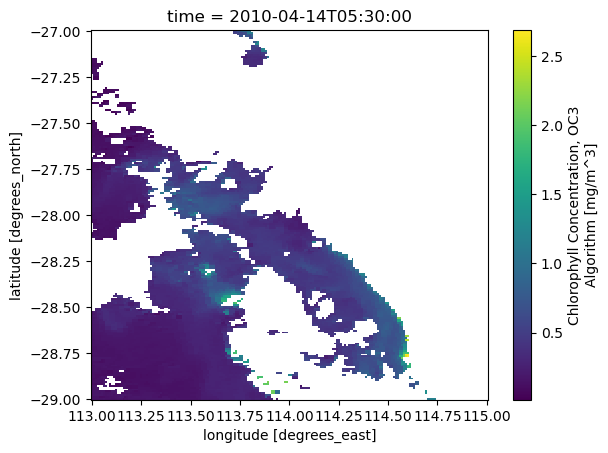

In [21]:
ch.chl_oc3.isel(time=103).plot()

### calculate MHW stats

In [22]:
sev_t

<xarray.Dataset> Size: 9kB
Dimensions:   (time: 549, zlev: 1)
Coordinates:
  * time      (time) datetime64[ns] 4kB 2010-07-01T12:00:00 ... 2011-12-31T12...
  * zlev      (zlev) float32 4B 0.0
    lat       float32 4B -27.88
    lon       float32 4B 113.9
Data variables:
    severity  (time, zlev) float32 2kB ...
    ssta      (time, zlev) float32 2kB ...

In [23]:
mhw_stats = MHW.calculate_MHWs_metrics(sev_t,maxEvt=15)

stats = mhw_stats.squeeze('zlev', drop=True)

# index of longest event
iev = stats['duration'].argmax(dim='event').item()

dur = int(stats['duration'].isel(event=iev).item())
imax = stats['intensity_max'].isel(event=iev).item()
imean = stats['intensity_mean'].isel(event=iev).item()
icum = stats['intensity_cumul'].isel(event=iev).item()

dstart = stats['date_start'].isel(event=iev).item()
dend   = stats['date_end'].isel(event=iev).item()
dpeak  = stats['date_peak'].isel(event=iev).item()

# sort out formatting

txt = (
    "Longest MHW\n"
    f"Start: {pd.to_datetime(dstart):%Y-%m-%d}\n"
    f"End:   {pd.to_datetime(dend):%Y-%m-%d}\n"
    f"Peak:  {pd.to_datetime(dpeak):%Y-%m-%d}\n"
    f"Dur:   {dur} d\n"
    f"Imax:  {imax:.2f} °C\n"
    f"Imean: {imean:.2f} °C\n"
    f"Icum:  {icum:.2f} °C·d"
)

### plot

In [24]:
def add_row_dot(fig, subplot_spec, x, color, size=120, dot_size=0.02):
    ss = subplot_spec.get_position(fig)
    y = 0.5 * (ss.y0 + ss.y1)
    ax_dot = fig.add_axes([x, y - dot_size/2, dot_size, dot_size])
    ax_dot.scatter(
    0.5, 0.5,
    s=200,
    color=color,          # fill
    edgecolor='black',    # border
    linewidth=1.0
)
    ax_dot.set_axis_off()
    return ax_dot

In [25]:
# ── Association row: data preparation ────────────────────────────────────────
assoc_start = "2011-01-10"
assoc_end   = "2011-03-15"

ch_sel = ch_tseries.sel(time=slice(assoc_start, assoc_end))
ts_sel = tseries.sel(time=slice(assoc_start, assoc_end))

ch_pd = ch_sel.to_series().sort_index()
ts_pd = ts_sel.to_series().sort_index()

# 14-day running mean
ch_smooth = ch_pd.rolling("14D", min_periods=1).mean()

# ── Scatter: detrend and align ─────────────────────────────────────────────
ch_df = ch_smooth.rename("ch").reset_index().sort_values("time")
ts_df = ts_pd.rename("ts").reset_index().sort_values("time")

scatter_df = pd.merge_asof(
    ch_df, ts_df,
    on="time", direction="nearest",
    tolerance=pd.Timedelta("1D")
).dropna()
scatter_df = scatter_df[scatter_df["ch"] > 0]

x = scatter_df["ch"].to_numpy()
y = scatter_df["ts"].to_numpy()
t = ((scatter_df["time"] - scatter_df["time"].min()).dt.total_seconds() / 86400).to_numpy()

mx_t, bx_t, *_ = linregress(t, x)
my_t, by_t, *_ = linregress(t, y)

x_detrended = x - (mx_t * t + bx_t)
y_detrended = y - (my_t * t + by_t)

slope, intercept, r_value, p_value, stderr = linregress(x_detrended, y_detrended)
x_fit = np.linspace(x_detrended.min(), x_detrended.max(), 200)
y_fit = slope * x_fit + intercept

Text(0.5, 0.97, '')

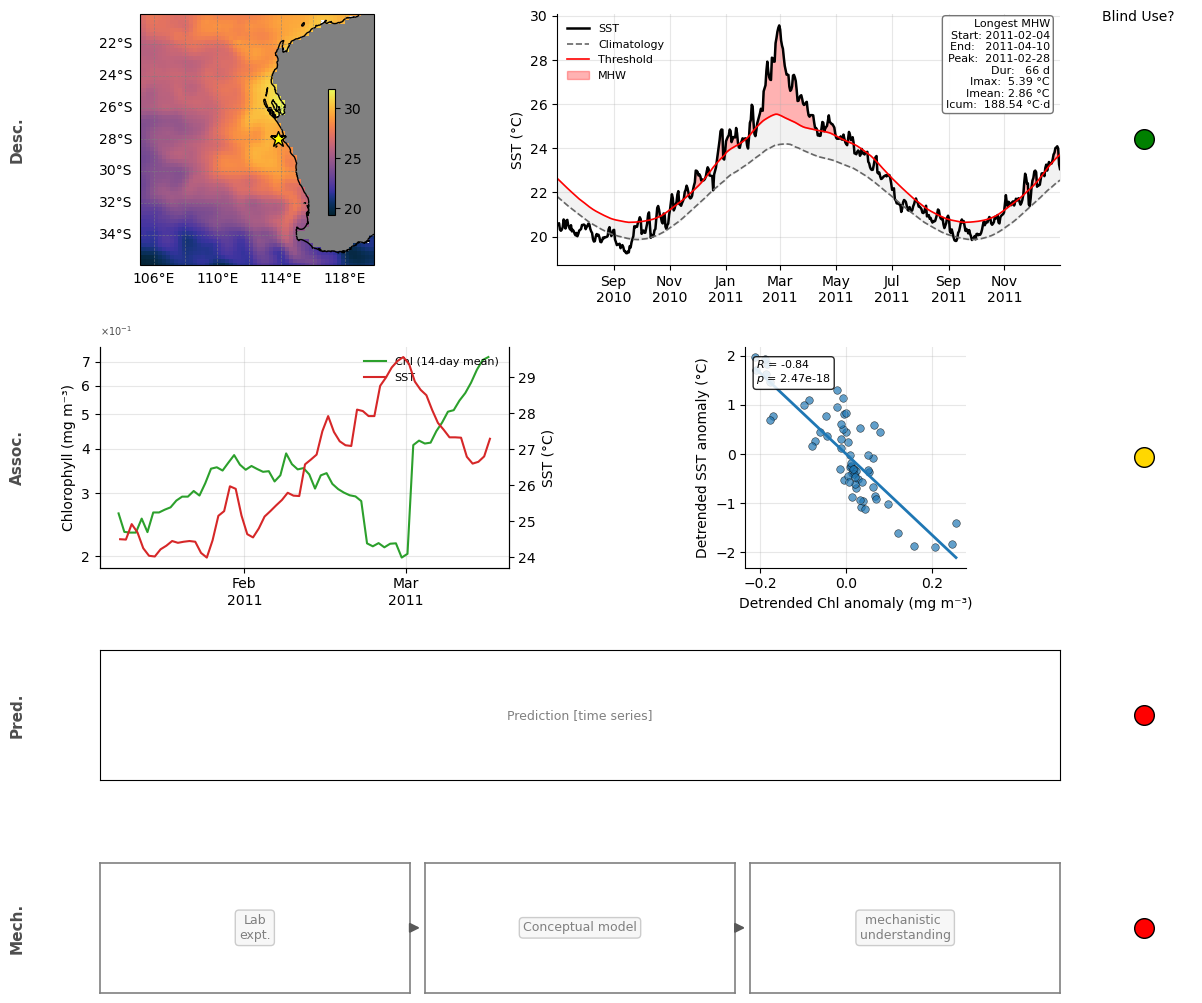

In [26]:
import matplotlib.ticker as mticker

fig = plt.figure(figsize=(12, 11))

# ── Top-level GridSpec: 4 rows ──────────────────────────────────────────────
gs_main = gridspec.GridSpec(
    4, 1,
    figure=fig,
    hspace=0.45,
    height_ratios=[2.5, 2.2, 1.3, 1.3],
    left=0.08, right=0.88, top=0.93, bottom=0.04,
)

# ── Row 0: Desc ─────────────────────────────────────────────────────────────
gs_desc = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_main[0], wspace=0.35, width_ratios=[1, 1.6]
)

ax_map = fig.add_subplot(gs_desc[0], projection=ccrs.PlateCarree())
plotmap(ds, ax=ax_map)

p = sst_day.plot(
    ax=ax_map,
    transform=ccrs.PlateCarree(),
    cmap=cmo.thermal,
    add_colorbar=False
)
ax_map.set_xlabel('')
ax_map.set_ylabel('')
ax_map.set_title('')
ax_map.plot(
    lon_s, lat_s,
    marker='*', markersize=12,
    markeredgecolor='black', markerfacecolor='yellow',
    transform=ccrs.PlateCarree()
)

cax = ax_map.inset_axes([0.8, 0.2, 0.03, 0.5])
cb = fig.colorbar(p, cax=cax)
cb.set_label('')

# MHW timeseries -------------------------------------------------------
ax_ts0 = fig.add_subplot(gs_desc[1])
time = tseries.time.values
sst  = tseries.values
clm  = clim_t.values
thr  = thresh_t.values

ax_ts0.plot(time, sst, color='k',   lw=1.8, label='SST')
ax_ts0.plot(time, clm, color='0.4', lw=1.2, ls='--', label='Climatology')
ax_ts0.plot(time, thr, color='r',   lw=1.2, label='Threshold')
ax_ts0.fill_between(time, thr, sst, where=(sst > thr),
                    interpolate=True, color='r', alpha=0.3, label='MHW')
ax_ts0.fill_between(time, clm, thr, color='0.8', alpha=0.25)

ax_ts0.grid(True, alpha=0.3)
ax_ts0.spines['top'].set_visible(False)
ax_ts0.spines['right'].set_visible(False)
ax_ts0.set_title('')
ax_ts0.set_xlabel('')
ax_ts0.set_ylabel('SST (°C)')
ax_ts0.legend(frameon=False, fontsize=8, loc='upper left')
ax_ts0.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax_ts0.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax_ts0.set_xlim(tseries.time.min().values, tseries.time.max().values)
ax_ts0.text(
    0.98, 0.98, txt,
    transform=ax_ts0.transAxes,
    ha='right', va='top', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.4', alpha=0.9)
)

# ── Row 1: Assoc ─────────────────────────────────────────────────────────────
gs_assoc = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_main[1], wspace=0.35
)

# Timeseries: SST + chlorophyll ----------------------------------------
ax_assoc_ts = fig.add_subplot(gs_assoc[0])

ax_assoc_ts.plot(ch_smooth.index, ch_smooth, color='tab:green', label='Chl (14-day mean)')
ax_assoc_ts.set_yscale('log')
# LogLocator with subs places ticks at every sub-decade (0.1, 0.2 … 0.9, 1 …)
# so there is something to label in a narrow log range.
# FuncFormatter renders each as a single integer (value × 10): 1, 2 … 9, 10 …
# offset-text and minor labels are suppressed so nothing doubles up.
ax_assoc_ts.yaxis.set_major_locator(
    mticker.LogLocator(base=10, subs=np.arange(1, 10))
)
ax_assoc_ts.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{round(x * 10):d}')
)
ax_assoc_ts.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_assoc_ts.yaxis.get_offset_text().set_visible(False)
ax_assoc_ts.text(
    0, 1.04, r'$\times 10^{-1}$',
    transform=ax_assoc_ts.transAxes,
    fontsize=7, ha='left', va='bottom', color='0.3'
)
ax_assoc_ts.set_ylabel('Chlorophyll (mg m⁻³)')
ax_assoc_ts.set_xlabel('')
ax_assoc_ts.xaxis.set_major_locator(mdates.MonthLocator())
ax_assoc_ts.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax_assoc_ts.grid(True, alpha=0.3)
ax_assoc_ts.spines['top'].set_visible(False)

ax_assoc_ts_r = ax_assoc_ts.twinx()
ax_assoc_ts_r.plot(ts_pd.index, ts_pd, color='tab:red', label='SST')
ax_assoc_ts_r.set_ylabel('SST (°C)')
ax_assoc_ts_r.spines['top'].set_visible(False)

lines1, labels1 = ax_assoc_ts.get_legend_handles_labels()
lines2, labels2 = ax_assoc_ts_r.get_legend_handles_labels()
ax_assoc_ts.legend(lines1 + lines2, labels1 + labels2,
                   frameon=False, fontsize=8, loc='upper right')

# Scatter: detrended Chl vs SST ----------------------------------------
ax_assoc_xy = fig.add_subplot(gs_assoc[1])
ax_assoc_xy.set_box_aspect(1)

ax_assoc_xy.scatter(
    x_detrended, y_detrended,
    s=30, alpha=0.7, edgecolor='k', linewidth=0.4
)
ax_assoc_xy.plot(x_fit, y_fit, lw=2, color='tab:blue')
ax_assoc_xy.set_xlabel('Detrended Chl anomaly (mg m⁻³)')
ax_assoc_xy.set_ylabel('Detrended SST anomaly (°C)')
ax_assoc_xy.grid(True, alpha=0.3)
ax_assoc_xy.spines['top'].set_visible(False)
ax_assoc_xy.spines['right'].set_visible(False)
ax_assoc_xy.text(
    0.05, 0.95, f"$R$ = {r_value:.2f}\n$p$ = {p_value:.3g}",
    transform=ax_assoc_xy.transAxes,
    va='top', fontsize=8,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)

# ── Row 2: Pred ─────────────────────────────────────────────────────────────
ax_pred = fig.add_subplot(gs_main[2])

# ── Row 3: Mech ─────────────────────────────────────────────────────────────
gs_mech = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs_main[3], wspace=0.05
)
ax_lab  = fig.add_subplot(gs_mech[0])
ax_mod  = fig.add_subplot(gs_mech[1])
ax_metn = fig.add_subplot(gs_mech[2])

# ── Small legend panel (top right, outside main grid) ───────────────────────
ax_legend = fig.add_axes([0.90, 0.78, 0.09, 0.14])

# ── Row labels ───────────────────────────────────────────────────────────────
row_labels = {
    gs_main[0]: "Desc.",
    gs_main[1]: "Assoc.",
    gs_main[2]: "Pred.",
    gs_main[3]: "Mech.",
}
label_x = 0.005
for gs_row, label in row_labels.items():
    ss = gs_row.get_position(fig)
    y_centre = (ss.y0 + ss.y1) / 2
    fig.text(label_x, y_centre, label,
             va="center", ha="left",
             fontsize=11, fontweight="bold",
             rotation=90, color="0.3")

# ── Mech arrows ─────────────────────────────────────────────────────────────
for ax_src, ax_dst in [(ax_lab, ax_mod), (ax_mod, ax_metn)]:
    p_src = ax_src.get_position()
    p_dst = ax_dst.get_position()
    x_start = p_src.x1
    x_end   = p_dst.x0
    y_mid   = (p_src.y0 + p_src.y1) / 2
    arrow = FancyArrowPatch(
        (x_start + 0.002, y_mid), (x_end - 0.002, y_mid),
        transform=fig.transFigure,
        arrowstyle="-|>",
        mutation_scale=14,
        color="0.35",
        linewidth=1.5,
        clip_on=False,
    )
    fig.add_artist(arrow)

# ── Traffic light dots ───────────────────────────────────────────────────────
add_row_dot(fig, gs_main[0], 0.94, 'green')
add_row_dot(fig, gs_main[1], 0.94, 'gold')
add_row_dot(fig, gs_main[2], 0.94, 'red')
add_row_dot(fig, gs_main[3], 0.94, 'red')

# ── Placeholder labels on remaining axes ────────────────────────────────────
axes_labels = {
    ax_pred:   ("Prediction [time series]", False),
    ax_lab:    ("Lab\nexpt.", True),
    ax_mod:    ("Conceptual model", True),
    ax_metn:   ("mechanistic \nunderstanding", True),
    ax_legend: ("", False),
}

for ax, (label, box) in axes_labels.items():
    ax.text(0.5, 0.5, label,
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=9, color="0.5",
            bbox=dict(boxstyle="round,pad=0.3", fc="0.97", ec="0.8") if box else None)
    if box:
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            spine.set_edgecolor("0.5")
    ax.set_xticks([])
    ax.set_yticks([])

ax_legend.set_title("Blind Use?", fontsize=10, pad=3)
for spine in ax_legend.spines.values():
    spine.set_visible(False)

fig.suptitle("", fontsize=14, color="0.4", y=0.97)

#plt.savefig("../plots/MHW_ID_hierarchy.png", dpi=150, bbox_inches="tight")
#plt.savefig("/mnt/user-data/outputs/figure_layout.pdf", bbox_inches="tight")